# ISP Simulation Analysis Tutorial

This tutorial demonstrates how to analyze In Silico Perturbation (ISP) simulation results (direct ISP in tumor cells) using the TMEformer framework. ISP is a powerful technique for studying how gene perturbations affect cell state transitions in the tumor microenvironment.

## Overview

In this tutorial, you will learn how to:
1. Run ISP simulations and load results
2. Compare target gene perturbation against background controls
3. Perform statistical analysis and visualize the results

## Prerequisites

Before running this notebook, you need to:
- Have the `TMEformer` package installed
- Run the ISP simulation script to generate perturbation results (see below)

### Step 0: Run ISP Simulation

First, execute the ISP simulation script to generate the perturbation results:

```bash
# Target ISP: Perturb a specific gene (e.g., AR)
tmeformer-emb-isp-target --device 1 \
--proj xenium --task ADT2CRPC \
--model_ids GF_D1120_06 \
--direction 'ADT>CRPC' \
--window 100 --endpoints 1 \
--gene_mode single --gene_list AR \
--cell_ratio 1000

# Background ISP: Perturb random genes as control
tmeformer-emb-isp-target --device 1 \
--proj xenium --task ADT2CRPC \
--model_ids GF_D1120_06 \
--direction 'ADT>CRPC' \
--window 100 --endpoints 1 \
--cell_ratio 5000 \
--background 1
```

> **Note**: The target perturbation tests the effect of a specific gene, while the background perturbation serves as a negative control using random genes.

## Step 1: Setup and Data Loading

Import required libraries, configure the working directory, and load metadata.

In [15]:
import os
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

import TMEformer.tme.TmeModeling_utils as tu
import TMEformer.tme.TmeModeling_utils_isp_sim as tu_isp_sim

In [16]:
# Set the base working directory
work_dir = "/dataSSD7T/liss/work/scPCa/model_paper/TMEformer-analysis/"
assert os.path.exists(work_dir), f"Working directory not found: {work_dir}"

In [17]:
# Load cell metadata
obsmeta = pd.read_csv(work_dir + "data/xenium/processed/xenium_obsmeta.csv")
obsmeta = obsmeta.rename(columns={"patch_2000": "patch_id"})

print(f"Loaded metadata with {len(obsmeta)} cells")
obsmeta.head()

Loaded metadata with 1495698 cells


,barcode,cell_id,sample_name,treat,treat2,Anno_01,spatial_1,spatial_2,n_genes_by_counts,total_counts,cell_type,tme_id,sample_id,patch_id
0,P005_aaaadolj-1,1,P005,P005_NT,NT,Stromal,19746.981458,16250.637695,294,447.0,Fibroblast,5,0,0_9_8
1,P005_aaaaghog-1,2,P005,P005_NT,NT,Stromal,19757.339490,16293.056641,190,223.0,Fibroblast,5,0,0_9_8
2,P005_aaaajnic-1,3,P005,P005_NT,NT,Stromal,19772.061231,16163.147705,441,722.0,Fibroblast,5,0,0_9_8
3,P005_aaaalmjd-1,4,P005,P005_NT,NT,T Cell,19782.952100,16050.635498,298,369.0,T_lymph,2,0,0_9_8
4,P005_aaaanlfi-1,5,P005,P005_NT,NT,Stromal,19764.207593,16153.165283,134,178.0,Fibroblast,5,0,0_9_8


## Step 2: Load and Process ISP Results

Configure the analysis task, select target and background conditions, and load ISP simulation results.

In [18]:
# Configure analysis parameters
task = "ADT2CRPC"
task_dir = work_dir + f"isp_emb_sim/task_{task}"
isp_type = "target_rank"

In [19]:
# Define target and background conditions
conditions_dict = {
    "Target": ["ADT2CRPC_ADT>CRPC-Target_Rank-L1-S1000-W100_EP1_KO0_KI0-AR"],
    "Background": ["ADT2CRPC_ADT>CRPC-Target_Rank-L1-S5000-W100_EP1_KO0_KI0-Background_C1"]
}
groups_ordered = ['Background_C1', 'AR']


In [20]:
# Select model
model_ids = ["GF_D1120_06"]

In [ ]:
# Merge ISP results for selected conditions
stats_raw = tu_isp_sim.merge_isp_sim_stat_raw(
    conditions_dict, task, model_ids, tme_isp=False, work_dir=work_dir
)

# Merge with metadata to get patch information
stats_raw = pd.merge(stats_raw, obsmeta[["cell_id", "patch_id"]])

In [24]:

# Filter and aggregate results at patch level
stats_filt = tu_isp_sim.filter_isp_sim_stat_raw(
    stats_raw, score_type="OE", score_method="endpoint", score_interval="[0, 1]",
    stat_level="patch", stat_method="mean", pair=True,
)

print(f"Loaded {len(stats_filt)} records")
print(f"Groups: {stats_filt['group'].unique()}")

Loaded 64 records
Groups: ['AR' 'Background_C1']


## Step 3: Statistical Analysis and Visualization

Perform statistical comparison and create box plot visualization with significance annotations.

In [25]:
# Calculate summary statistics and p-values
stats_pval = tu_isp_sim.calc_summary_stat_pvals(
    stats_filt, stat_level="patch", stat_method="mean", wilcoxon_test="less"
)
print("Statistical Summary:")
stats_pval

Statistical Summary:


,model_id,Background_C1,AR,p_value,log_p,log_p_cut
0,GF_D1120_06,0.000235,0.00036,0.001933,2.713814,2.713814


In [26]:
# Configure visualization parameters
palette_dict = {
    groups_ordered[0]: "grey",       # Background in grey
    groups_ordered[1]: "#ff7f0e",    # Target in orange
}

plot_params = {
    "x": "group",
    "order": groups_ordered,
    "hue": "group",
    "width": 0.5,
    "palette": palette_dict,
    "showfliers": True,
    "flierprops": dict(marker='o', markersize=1),
}


[('Background_C1', 'AR')]
p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

Background_C1 vs. AR: Paired Wilcoxon test (one-sided), P_val:1.933e-03 Stat=1.130e+02


/dataSSD7T/liss/work/scPCa/model/TMEformer-repo/TMEformer/tme/TmeModeling_utils_isp_sim.py:541: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(title=None)
/dataSSD7T/liss/work/scPCa/model/TMEformer-repo/TMEformer/tme/TmeModeling_utils_isp_sim.py:544: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(


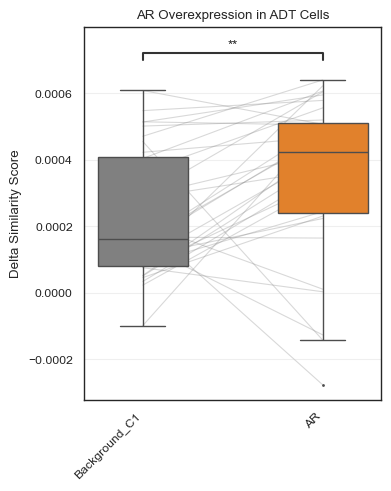

In [27]:

# Create the visualization
sns.set_theme(context='paper', style='white')

tu_isp_sim.vis_delta_emb_sim_boxbar(
    stats_filt,
    title_text="AR Overexpression in ADT Cells",
    ylabel_text="Delta Similarity Score",
    figsize=(4, 5),
    wilcoxon_test="less",
    line=True,
    line_params=None,
    pair_id_col="patch_id",
    **plot_params
)

plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

## Interpretation

The plot shows the distribution of delta similarity scores for:
- **Background_C1**: Random gene perturbations (control)
- **AR**: AR gene overexpression (target)

Key points to interpret:
1. **Higher scores** indicate greater similarity to the CRPC state
2. **Statistical significance** (p-value from one sided Wilcoxon test) indicates whether AR perturbation has higher effect than random genes